## Importing Dependencies

In [1]:
import pandas as pd
import joblib
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import torch.nn as nn
from data_fetching import BinanceDataExtractor
from datetime import datetime
import numpy as np

## Setting timeframe for data retrieval

In [2]:
start_time = datetime(2024, 11, 21, 0, 0, 0)
end_time = datetime(2024, 11, 28, 0, 0, 0)
start_ts = '2024-11-21 00:00:00'

## Extracing data using Binance API

In [3]:
extractor = BinanceDataExtractor(start_time, start_ts, end_time)

In [4]:
ohlcv, order_book = extractor.runner()

Fetching OHLCV Data:   0%|          | 0/50 [00:00<?, ?Trading Pair/s]

Fetching Order Book Data:   0%|          | 0/16850 [00:00<?, ?requests/s]

## Displaying Data

In [10]:
ohlcv

,Trading Pair,Open,High,Low,Close,Volume,24-Hour Volume
Timestamp,,,,,,,
2024-11-21 00:00:00,BTC/FDUSD,94541.76,95126.50,94413.28,95053.23,747.36790,0.00
2024-11-21 00:30:00,BTC/FDUSD,95047.98,95166.21,94805.19,94936.05,714.03529,0.00
2024-11-21 01:00:00,BTC/FDUSD,94937.49,95208.29,94812.00,95128.47,622.84358,0.00
2024-11-21 01:30:00,BTC/FDUSD,95122.36,95149.64,94872.95,94931.80,445.14555,0.00
2024-11-21 02:00:00,BTC/FDUSD,94934.69,95007.89,94378.99,94464.57,743.18585,0.00
...,...,...,...,...,...,...,...
2024-11-30 15:00:00,LINK/USDT,18.51,18.80,18.46,18.78,184091.00000,4503503.64
2024-11-30 15:30:00,LINK/USDT,18.78,18.97,18.74,18.88,203198.73000,4537094.11
2024-11-30 16:00:00,LINK/USDT,18.88,19.18,18.69,18.71,437358.78000,4785476.49


In [11]:
order_book

,Timestamp,Trading Pair,Bid Price_mean,Bid Price_max,Bid Price_min,Bid Quantity_mean,Bid Quantity_sum,Ask Price_mean,Ask Price_max,Ask Price_min,Ask Quantity_mean,Ask Quantity_sum,Bid Price Mean Change,Bid Quantity Mean Change,Ask Price Mean Change,Ask Quantity Mean Change,Bid Price Rolling Mean,Ask Price Rolling Mean,Bid Quantity Rolling Sum,Ask Quantity Rolling Sum
0,2024-11-21 00:00:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.065824,-0.008288,-0.069391,-0.262971,-0.262973,-0.175752,-0.176655
1,2024-11-21 00:30:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.023491,-0.008288,-0.080079,-0.262971,-0.262973,-0.175752,-0.176655
2,2024-11-21 01:00:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.065824,-0.008288,-0.069391,-0.262971,-0.262973,-0.175752,-0.176655
3,2024-11-21 01:30:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.065824,-0.008288,-0.069391,-0.262971,-0.262973,-0.175752,-0.176655
4,2024-11-21 02:00:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.221509,-0.008288,-0.059594,-0.262945,-0.262946,-0.175745,-0.176636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16845,2024-11-27 22:00:00,XRP/USDT,-0.264573,-0.264574,-0.264573,-0.176831,-0.176831,-0.264575,-0.264575,-0.264574,-0.177697,-0.177697,1.142000,-0.055801,1.176617,-0.898035,-0.262888,-0.262890,-0.175746,-0.176646
16846,2024-11-27 22:30:00,XRP/USDT,-0.264573,-0.264574,-0.264573,-0.176830,-0.176830,-0.264575,-0.264575,-0.264574,-0.177697,-0.177697,-0.007623,0.487493,-0.008288,-0.389470,-0.262888,-0.262890,-0.175746,-0.176647
16847,2024-11-27 23:00:00,XRP/USDT,-0.264573,-0.264574,-0.264573,-0.176830,-0.176830,-0.264575,-0.264575,-0.264574,-0.177697,-0.177697,-0.007623,-0.065824,-0.008288,-0.069391,-0.262888,-0.262890,-0.175746,-0.176647
16848,2024-11-27 23:30:00,XRP/USDT,-0.264573,-0.264574,-0.264573,-0.176829,-0.176829,-0.264575,-0.264575,-0.264574,-0.177697,-0.177697,0.567128,0.272943,0.584102,0.170849,-0.262888,-0.262890,-0.175745,-0.176648


Since the shape of order book and OHLCV data is different, we will set timestamp thresholds to only use consistent data format.

## Data preparation

In [14]:
threshold_timestamp = pd.to_datetime('2024-11-28 00:00:00')

In [15]:
ohlcv = ohlcv.reset_index()

In [20]:
ohlcv = ohlcv[ohlcv['Timestamp'] <= threshold_timestamp]

In [97]:
ohlcv['Trading Pair'].unique().shape

(49,)

In [98]:
order_book['Trading Pair'].unique().shape

(49,)

In [ ]:
ohlcv_trading_pairs = ohlcv['Trading Pair'].unique()
order_book = order_book[order_book['Trading Pair'].isin(ohlcv_trading_pairs)].set_index('Timestamp')

In [25]:
ohlcv = ohlcv.sort_values(by=['Trading Pair', 'Timestamp']).set_index('Timestamp')

In [26]:
order_book

,Trading Pair,Bid Price_mean,Bid Price_max,Bid Price_min,Bid Quantity_mean,Bid Quantity_sum,Ask Price_mean,Ask Price_max,Ask Price_min,Ask Quantity_mean,Ask Quantity_sum,Bid Price Mean Change,Bid Quantity Mean Change,Ask Price Mean Change,Ask Quantity Mean Change,Bid Price Rolling Mean,Ask Price Rolling Mean,Bid Quantity Rolling Sum,Ask Quantity Rolling Sum
Timestamp,,,,,,,,,,,,,,,,,,,
2024-11-21 00:00:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.065824,-0.008288,-0.069391,-0.262971,-0.262973,-0.175752,-0.176655
2024-11-21 00:30:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.023491,-0.008288,-0.080079,-0.262971,-0.262973,-0.175752,-0.176655
2024-11-21 01:00:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.065824,-0.008288,-0.069391,-0.262971,-0.262973,-0.175752,-0.176655
2024-11-21 01:30:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.065824,-0.008288,-0.069391,-0.262971,-0.262973,-0.175752,-0.176655
2024-11-21 02:00:00,ACT/USDT,-0.264629,-0.264630,-0.264629,-0.176830,-0.176830,-0.264631,-0.264631,-0.264630,-0.177685,-0.177685,-0.007623,-0.221509,-0.008288,-0.059594,-0.262945,-0.262946,-0.175745,-0.176636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-27 22:00:00,XRP/USDT,-0.264573,-0.264574,-0.264573,-0.176831,-0.176831,-0.264575,-0.264575,-0.264574,-0.177697,-0.177697,1.142000,-0.055801,1.176617,-0.898035,-0.262888,-0.262890,-0.175746,-0.176646
2024-11-27 22:30:00,XRP/USDT,-0.264573,-0.264574,-0.264573,-0.176830,-0.176830,-0.264575,-0.264575,-0.264574,-0.177697,-0.177697,-0.007623,0.487493,-0.008288,-0.389470,-0.262888,-0.262890,-0.175746,-0.176647
2024-11-27 23:00:00,XRP/USDT,-0.264573,-0.264574,-0.264573,-0.176830,-0.176830,-0.264575,-0.264575,-0.264574,-0.177697,-0.177697,-0.007623,-0.065824,-0.008288,-0.069391,-0.262888,-0.262890,-0.175746,-0.176647


In [27]:
ohlcv

,Trading Pair,Open,High,Low,Close,Volume,24-Hour Volume
Timestamp,,,,,,,
2024-11-21 00:00:00,ACT/USDT,0.4948,0.5130,0.4941,0.5097,7972598.6,1.849537e+07
2024-11-21 00:30:00,ACT/USDT,0.5096,0.5110,0.4996,0.5002,4218525.9,2.268725e+07
2024-11-21 01:00:00,ACT/USDT,0.5002,0.5077,0.4970,0.5076,3002525.3,2.566429e+07
2024-11-21 01:30:00,ACT/USDT,0.5076,0.5077,0.4980,0.4989,2336020.4,2.798394e+07
2024-11-21 02:00:00,ACT/USDT,0.4988,0.4993,0.4600,0.4633,19956541.6,4.793109e+07
...,...,...,...,...,...,...,...
2024-11-27 22:00:00,XRP/USDT,1.4939,1.4980,1.4743,1.4871,14850512.0,5.873082e+08
2024-11-27 22:30:00,XRP/USDT,1.4872,1.4933,1.4750,1.4764,5996553.0,5.867857e+08
2024-11-27 23:00:00,XRP/USDT,1.4764,1.4823,1.4670,1.4717,12652827.0,5.919167e+08


Since there is still discrepancy in shapes despite collecting data between consistent timeframes, we need to analyze the value counts to detect any errors in data collection.

In [28]:
order_book['Trading Pair'].value_counts()

Trading Pair
ACT/USDT      337
THE/USDT      337
NEAR/USDT     337
NEIRO/USDT    337
PEPE/USDT     337
PNUT/USDT     337
RUNE/USDT     337
SAND/USDT     337
SHIB/USDT     337
SOL/FDUSD     337
SOL/USDT      337
SUI/USDT      337
THETA/USDT    337
ADA/USDT      337
TIA/USDT      337
UNI/USDT      337
USDC/USDT     337
USDT/TRY      337
WIF/USDT      337
WLD/USDT      337
XLM/USDT      337
XRP/BTC       337
XRP/FDUSD     337
XRP/USDC      337
LTC/USDT      337
LINK/USDT     337
HBAR/USDT     337
FTM/USDT      337
ALGO/USDT     337
ARB/USDT      337
AVAX/USDT     337
BNB/FDUSD     337
BNB/USDT      337
BTC/FDUSD     337
BTC/USDC      337
BTC/USDT      337
DOGE/FDUSD    337
DOGE/USDT     337
DOT/USDT      337
ENA/USDT      337
ENS/USDT      337
ETH/BTC       337
ETH/FDUSD     337
ETH/USDC      337
ETH/USDT      337
FDUSD/USDT    337
FET/USDT      337
FIDA/USDT     337
FIL/USDT      337
XRP/USDT      337
Name: count, dtype: int64

In [29]:
ohlcv['Trading Pair'].value_counts()

Trading Pair
ACT/USDT      337
ADA/USDT      337
NEAR/USDT     337
NEIRO/USDT    337
PEPE/USDT     337
PNUT/USDT     337
RUNE/USDT     337
SAND/USDT     337
SHIB/USDT     337
SOL/FDUSD     337
SOL/USDT      337
SUI/USDT      337
THETA/USDT    337
TIA/USDT      337
UNI/USDT      337
USDC/USDT     337
USDT/TRY      337
WIF/USDT      337
WLD/USDT      337
XLM/USDT      337
XRP/BTC       337
XRP/FDUSD     337
XRP/USDC      337
LTC/USDT      337
LINK/USDT     337
HBAR/USDT     337
DOT/USDT      337
ALGO/USDT     337
ARB/USDT      337
AVAX/USDT     337
BNB/FDUSD     337
BNB/USDT      337
BTC/FDUSD     337
BTC/USDC      337
BTC/USDT      337
DOGE/FDUSD    337
DOGE/USDT     337
XRP/USDT      337
FTM/USDT      337
ENA/USDT      337
ENS/USDT      337
ETH/BTC       337
ETH/FDUSD     337
ETH/USDC      337
ETH/USDT      337
FDUSD/USDT    337
FET/USDT      337
FIDA/USDT     337
FIL/USDT      337
THE/USDT       29
Name: count, dtype: int64

As evident, **THE/USDT** pair has only 29 rows of data compared to other trading pairs that have 337 rows. Thus, we need to drop this pair off of both dataframes.

In [30]:
ohlcv = ohlcv[~(ohlcv['Trading Pair'] == 'THE/USDT')]

In [31]:
order_book = order_book[~(order_book['Trading Pair'] == 'THE/USDT')]

In [32]:
print(ohlcv.shape)
print(order_book.shape)

(16513, 7)
(16513, 19)


The data is now in a consistent form, with same number of rows. Thus, we merge them into a single table.

In [36]:
df = pd.merge(ohlcv, order_book, on=['Timestamp', 'Trading Pair'], how='inner')

## Normalizing data

In [37]:
def normalize_pair_data(df, columns):    
    scaler = StandardScaler()
    
    df_normalized = df.groupby('Trading Pair').apply(
        lambda group: group.assign(
            **{col: scaler.fit_transform(group[[col]]) for col in columns}
        )
    )
    
    return df_normalized

In [38]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
df = normalize_pair_data(df, list(numerical_columns))
df = df.reset_index(level='Trading Pair', drop=True)

/tmp/ipykernel_1350633/850294643.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_normalized = df.groupby('Trading Pair').apply(


## Testing with Isolation Forest

In [39]:
isolation_forest = joblib.load('isolation_forest_model.pkl')
result_df = df.copy()

In [40]:
X_test = result_df.drop('Trading Pair', axis=1).values
isolation_scores = isolation_forest.decision_function(X_test)
isolation_predictions = isolation_forest.predict(X_test)   
result_df['IsolationForest_Score'] = isolation_scores
result_df['IsolationForest_Prediction'] = isolation_predictions 

/home/shahmir/miniconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/home/shahmir/miniconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [41]:
result_df[['Trading Pair', 'IsolationForest_Score', 'IsolationForest_Prediction']]

,Trading Pair,IsolationForest_Score,IsolationForest_Prediction
Timestamp,,,
2024-11-21 00:00:00,ACT/USDT,-0.058984,-1
2024-11-21 00:30:00,ACT/USDT,-0.057533,-1
2024-11-21 01:00:00,ACT/USDT,-0.057533,-1
2024-11-21 01:30:00,ACT/USDT,-0.058311,-1
2024-11-21 02:00:00,ACT/USDT,0.056381,1
...,...,...,...
2024-11-27 22:00:00,XRP/USDT,0.068189,1
2024-11-27 22:30:00,XRP/USDT,0.083486,1
2024-11-27 23:00:00,XRP/USDT,0.107103,1


In [42]:
filtered_df = result_df[result_df['IsolationForest_Prediction'] == -1]
count_per_pair = filtered_df['Trading Pair'].value_counts()
sorted_count = count_per_pair.sort_values(ascending=False)
sorted_count.head(20)

Trading Pair
XRP/FDUSD     26
ETH/FDUSD     23
ETH/BTC       20
PNUT/USDT     20
XRP/USDT      19
WLD/USDT      17
XRP/USDC      16
ETH/USDC      16
ETH/USDT      15
THETA/USDT    14
HBAR/USDT     13
FET/USDT      13
ARB/USDT      12
BNB/FDUSD     12
ADA/USDT      11
SAND/USDT     11
FIDA/USDT     11
ENA/USDT      10
XRP/BTC        9
SUI/USDT       9
Name: count, dtype: int64

## Testing with Autoencoders

In [43]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [44]:
X_test = df.drop('Trading Pair', axis=1).values
input_dim = X_test.shape[1]
hidden_dim = 64
autoencoder = Autoencoder(input_dim=input_dim, hidden_dim=hidden_dim)


In [45]:
autoencoder.load_state_dict(torch.load('autoencoder_model.pth', map_location=torch.device('cpu')))
autoencoder.eval()

/tmp/ipykernel_1350633/1890242110.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load('autoencoder_model.pth', map_location=torch.devi

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=24, bias=True)
    (3): Sigmoid()
  )
)

In [46]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [47]:
with torch.no_grad():
    reconstructed_test = autoencoder(X_test_tensor)

In [48]:
test_reconstruction_error = torch.mean((reconstructed_test - X_test_tensor) ** 2, dim=1).numpy()
threshold = np.percentile(test_reconstruction_error, 95)
test_anomalies = test_reconstruction_error > threshold
result_df['Autoencoder_ReconstructionError'] = test_reconstruction_error
result_df['Autoencoder_Anomaly'] = test_anomalies.astype(int)  

In [49]:
anomaly_rate = np.mean(test_anomalies) * 100
print(f"Anomaly Rate: {anomaly_rate:.2f}%")

Anomaly Rate: 5.00%


In [50]:
print(f"Mean Reconstruction Error: {np.mean(test_reconstruction_error):.4f}")
print(f"Standard Deviation: {np.std(test_reconstruction_error):.4f}")
print(f"Anomaly Threshold (95th Percentile): {threshold:.4f}")

Mean Reconstruction Error: 0.9087
Standard Deviation: 1.4776
Anomaly Threshold (95th Percentile): 2.2968


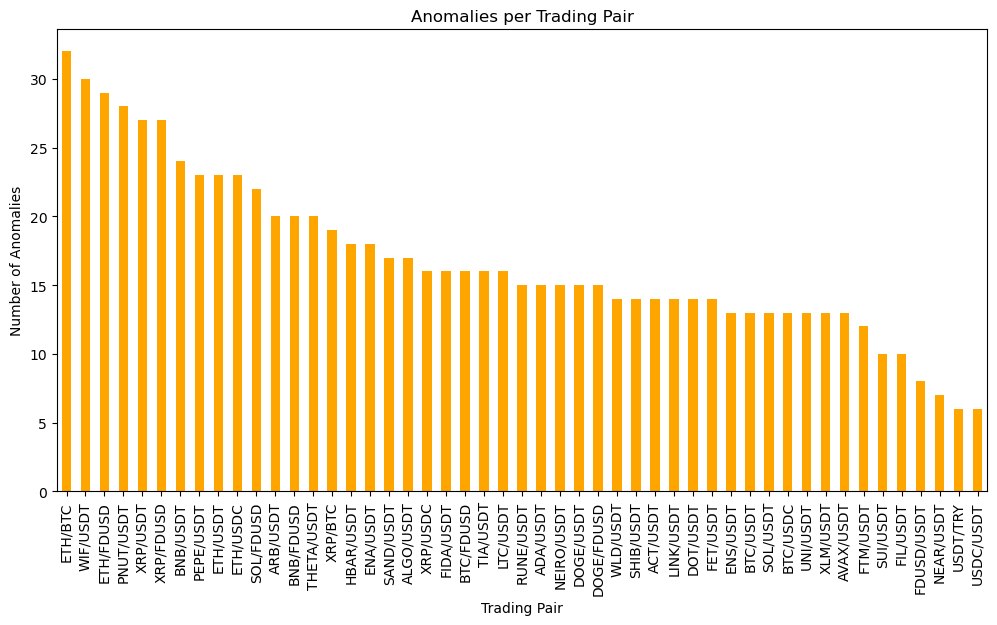

In [73]:
anomaly_df = result_df[result_df['Autoencoder_Anomaly'] == 1]
anomaly_counts = anomaly_df['Trading Pair'].value_counts()

plt.figure(figsize=(12, 6))
anomaly_counts.plot(kind='bar', color='orange')
plt.title("Anomalies per Trading Pair")
plt.xlabel("Trading Pair")
plt.ylabel("Number of Anomalies")
plt.show()

## Results

In [78]:
total_samples = len(result_df)
autoencoder_anomalies = result_df['Autoencoder_Anomaly'].sum()
isolation_forest_anomalies = (result_df['IsolationForest_Prediction'] == -1).sum()

anomaly_rate_autoencoder = (autoencoder_anomalies / total_samples) * 100
anomaly_rate_isolation = (isolation_forest_anomalies / total_samples) * 100

print(f"Total Samples: {total_samples}")
print(f"Autoencoder - Anomalies: {autoencoder_anomalies}, Anomaly Rate: {anomaly_rate_autoencoder:.2f}%")
print(f"Isolation Forest - Anomalies: {isolation_forest_anomalies}, Anomaly Rate: {anomaly_rate_isolation:.2f}%")

Total Samples: 16513
Autoencoder - Anomalies: 826, Anomaly Rate: 5.00%
Isolation Forest - Anomalies: 443, Anomaly Rate: 2.68%


In [90]:
overview_data = {
    "Metric": [
        "Total Samples Analyzed",
        "Number of Anomalies",
        "Anomaly Rate (%)",
        "Mean Reconstruction/Isolation Score",
        "Standard Deviation of Error/Score",
        "Threshold for Anomaly"
    ],
    "Autoencoder": [
        len(result_df),
        result_df['Autoencoder_Anomaly'].sum(),
        (result_df['Autoencoder_Anomaly'].sum() / len(result_df)) * 100,
        result_df['Autoencoder_ReconstructionError'].mean(),
        result_df['Autoencoder_ReconstructionError'].std(),
        np.percentile(result_df['Autoencoder_ReconstructionError'], 95)
    ],
    "Isolation Forest": [
        len(result_df),
        (result_df['IsolationForest_Prediction'] == -1).sum(),
        ((result_df['IsolationForest_Prediction'] == -1).sum() / len(result_df)) * 100,
        result_df['IsolationForest_Score'].mean(),
        result_df['IsolationForest_Score'].std(),
        "Score < 0"
    ]
}

overview_table = pd.DataFrame(overview_data)

trading_pair_analysis = result_df.groupby('Trading Pair').agg({
    'Autoencoder_Anomaly': 'sum',
    'IsolationForest_Prediction': lambda x: (x == -1).sum(),
    'Autoencoder_ReconstructionError': 'mean',
    'IsolationForest_Score': 'mean'
}).rename(columns={
    'Autoencoder_Anomaly': 'Autoencoder Anomalies',
    'IsolationForest_Prediction': 'Isolation Forest Anomalies',
    'Autoencoder_ReconstructionError': 'Mean Autoencoder Error',
    'IsolationForest_Score': 'Mean Isolation Score'
}).reset_index()

error_distribution = {
    "Statistic": ["Min", "25th Percentile", "Median", "75th Percentile", "Max"],
    "Autoencoder Error": [
        result_df['Autoencoder_ReconstructionError'].min(),
        np.percentile(result_df['Autoencoder_ReconstructionError'], 25),
        np.percentile(result_df['Autoencoder_ReconstructionError'], 50),
        np.percentile(result_df['Autoencoder_ReconstructionError'], 75),
        result_df['Autoencoder_ReconstructionError'].max()
    ],
    "Isolation Forest Score": [
        result_df['IsolationForest_Score'].min(),
        np.percentile(result_df['IsolationForest_Score'], 25),
        np.percentile(result_df['IsolationForest_Score'], 50),
        np.percentile(result_df['IsolationForest_Score'], 75),
        result_df['IsolationForest_Score'].max()
    ]
}

error_distribution_table = pd.DataFrame(error_distribution)

anomaly_counts_data = {
    "Trading Pair": result_df['Trading Pair'].unique(),
    "Autoencoder Anomalies": trading_pair_analysis['Autoencoder Anomalies'],
    "Isolation Forest Anomalies": trading_pair_analysis['Isolation Forest Anomalies'],
    "Autoencoder Anomaly Rate (%)": trading_pair_analysis['Autoencoder Anomalies'] / len(result_df) * 100,
    "Isolation Forest Anomaly Rate (%)": trading_pair_analysis['Isolation Forest Anomalies'] / len(result_df) * 100,
}

anomaly_counts_table = pd.DataFrame(anomaly_counts_data)


In [91]:
overview_table

,Metric,Autoencoder,Isolation Forest
0,Total Samples Analyzed,16513.000000,16513
1,Number of Anomalies,826.000000,443
2,Anomaly Rate (%),5.002120,2.682735
3,Mean Reconstruction/Isolation Score,0.908748,0.110726
4,Standard Deviation of Error/Score,1.477613,0.044006
5,Threshold for Anomaly,2.296831,Score < 0


In [92]:
error_distribution_table

,Statistic,Autoencoder Error,Isolation Forest Score
0,Min,0.055843,-0.129456
1,25th Percentile,0.340610,0.089230
2,Median,0.568227,0.121692
3,75th Percentile,0.935751,0.142360
4,Max,39.702435,0.178023


In [93]:
trading_pair_analysis

,Trading Pair,Autoencoder Anomalies,Isolation Forest Anomalies,Mean Autoencoder Error,Mean Isolation Score
0,ACT/USDT,14,7,0.935704,0.100772
1,ADA/USDT,15,11,0.916228,0.107554
2,ALGO/USDT,17,7,0.923343,0.110129
3,ARB/USDT,20,12,0.924111,0.114000
4,AVAX/USDT,13,5,0.925451,0.118579
5,BNB/FDUSD,20,12,0.910404,0.103759
6,BNB/USDT,24,9,0.931793,0.111200
7,BTC/FDUSD,16,4,0.924098,0.096099
8,BTC/USDC,13,8,0.932517,0.101735
9,BTC/USDT,13,2,0.940240,0.114486


In [94]:
anomaly_counts_table

,Trading Pair,Autoencoder Anomalies,Isolation Forest Anomalies,Autoencoder Anomaly Rate (%),Isolation Forest Anomaly Rate (%)
0,ACT/USDT,14,7,0.084782,0.042391
1,ADA/USDT,15,11,0.090838,0.066614
2,ALGO/USDT,17,7,0.102949,0.042391
3,ARB/USDT,20,12,0.121117,0.072670
4,AVAX/USDT,13,5,0.078726,0.030279
5,BNB/FDUSD,20,12,0.121117,0.072670
6,BNB/USDT,24,9,0.145340,0.054503
7,BTC/FDUSD,16,4,0.096893,0.024223
8,BTC/USDC,13,8,0.078726,0.048447
9,BTC/USDT,13,2,0.078726,0.012112
